# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Nick Powell, Chris Hubbard*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [ ]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>

!git clone https://github.com/NickPowell2004/IT480-FA26.git

In [10]:
# Your imports here

import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [11]:
# Load train.csv here

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [12]:
# Write your image-loading function here

X_train = x_train.astype("float32") / 255.0
X_test = x_test.astype("float32") / 255.0

In [13]:
# Build X and y, then split into train/test here

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [33]:
# Build your CNN model here

model = Sequential()

# First CNN Layer
model.add(Conv2D(32, kernel_size = 3, activation = 'relu', input_shape = (28, 28, 1)))
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# Second CNN Layer
model.add(Conv2D(64, kernel_size = 3, activation = 'relu'))
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# Flatten the feature maps
model.add(Flatten())

# Output Layer
model.add(Dense(10, activation = 'softmax'))

In [41]:
# Compile your model here

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

*Your architecture justification (one paragraph):*




---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [42]:
# Train your model here (save the result as `history`)

history = model.fit(X_train, y_train, epochs = 10, validation_data = (X_test, y_test), batch_size = 64)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - accuracy: 0.8092 - loss: 0.5310 - val_accuracy: 0.8586 - val_loss: 0.3963
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.8717 - loss: 0.3551 - val_accuracy: 0.8701 - val_loss: 0.3609
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.8867 - loss: 0.3128 - val_accuracy: 0.8789 - val_loss: 0.3430
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.8978 - loss: 0.2858 - val_accuracy: 0.8930 - val_loss: 0.2998
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9047 - loss: 0.2641 - val_accuracy: 0.8855 - val_loss: 0.3153
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9094 - loss: 0.2491 - val_accuracy: 0.8972 - val_loss: 0.2794
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.9147 - loss: 0.2362 - val_accuracy: 0.8846 - val_loss: 0.3047
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.9186 - loss: 0.2236 - 

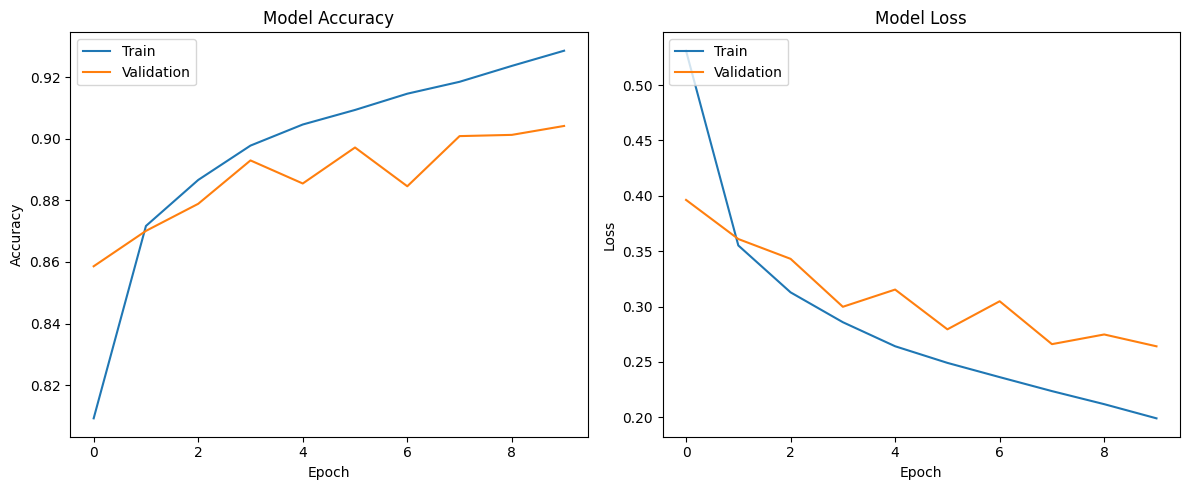

In [44]:
# Plot training vs. validation loss and accuracy here

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

*Your fit diagnosis, with specific evidence from your curve:*

The CNN model has some slight overfitting within the model, with the training accuracy reaching ~92%, while the validation accuracy is reaching ~90% after epoch 10.



In [45]:
# Evaluate on the test set and report accuracy here

loss, accuracy = model.evaluate(X_test, y_test, verbose = 0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 0.9042
Test Loss: 0.2641


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*




In [ ]:
# Build your improved model here



In [ ]:
# Train your improved model here



---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | | |
| Fit pattern (good/over/under) | | |
| What changed | | |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

In [ ]:
# Evaluate your improved model and build a confusion matrix here



*Your discussion of the confusion matrix:*




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

In [ ]:
# Find and display misclassified images here



*Your observations about the misclassified images:*




---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.